In [156]:
import pandas as pd
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from sklearn.preprocessing import LabelEncoder

In [157]:
img_path = []
labels = []

for kind in os.listdir('/kaggle/input/animal-faces/afhq'):
    for label in os.listdir(f'/kaggle/input/animal-faces/afhq/{kind}'):
        for image in os.listdir(f'/kaggle/input/animal-faces/afhq/{kind}/{label}'):
            labels.append(label)
            img_path.append(f'/kaggle/input/animal-faces/afhq/{kind}/{label}/{image}')

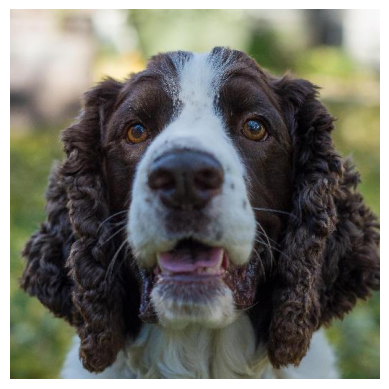

In [158]:
# Path to imag
img_test = img_path[0]

# Open image
image = Image.open(img_test)

# Show image
plt.imshow(image)
plt.axis("off")   # remove axis
plt.show()

In [159]:
data = pd.DataFrame({"Path" : img_path, "label": labels})
data.head()

,Path,label
0,/kaggle/input/animal-faces/afhq/val/dog/flickr...,dog
1,/kaggle/input/animal-faces/afhq/val/dog/pixaba...,dog
2,/kaggle/input/animal-faces/afhq/val/dog/flickr...,dog
3,/kaggle/input/animal-faces/afhq/val/dog/flickr...,dog
4,/kaggle/input/animal-faces/afhq/val/dog/pixaba...,dog


In [160]:
data.shape

(16130, 2)

In [161]:
data['label'].unique()

array(['dog', 'wild', 'cat'], dtype=object)

In [162]:
le = LabelEncoder()
encoded_labels = le.fit_transform(data["label"])
print(encoded_labels)

decoded_labels = le.inverse_transform(encoded_labels)
print(decoded_labels)

[1 1 1 ... 0 0 0]
['dog' 'dog' 'dog' ... 'cat' 'cat' 'cat']


In [163]:
data["encoded_labels"] = encoded_labels
data.head()

,Path,label,encoded_labels
0,/kaggle/input/animal-faces/afhq/val/dog/flickr...,dog,1
1,/kaggle/input/animal-faces/afhq/val/dog/pixaba...,dog,1
2,/kaggle/input/animal-faces/afhq/val/dog/flickr...,dog,1
3,/kaggle/input/animal-faces/afhq/val/dog/flickr...,dog,1
4,/kaggle/input/animal-faces/afhq/val/dog/pixaba...,dog,1


In [164]:
train_data = data.sample(frac = 0.7, random_state=7)
test_data = data.drop(train_data.index)
val_data = test_data.sample(frac = 0.5, random_state=7)
test_data = test_data.drop(val_data.index)

train_data.shape, test_data.shape , val_data.shape

((11291, 3), (2419, 3), (2420, 3))

In [165]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [166]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [167]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform = None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.dataframe.iloc[idx, 2]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(label, dtype=torch.long)

        return image, label
        

In [168]:
train_dataset = CustomImageDataset(dataframe=train_data, transform=transform)
val_dataset = CustomImageDataset(dataframe=val_data, transform=transform)
test_dataset = CustomImageDataset(dataframe=test_data, transform=transform)

In [169]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 8


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [170]:
import torch.nn as nn

class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.CNN_Layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.FC_Layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 16 * 128, 128),  
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.CNN_Layers(x)
        x = self.FC_Layers(x)
        return x


model = Model().to(device)

In [171]:
from torchsummary import summary
summary(model, input_size = (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
              ReLU-2         [-1, 32, 128, 128]               0
         MaxPool2d-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
              ReLU-5           [-1, 64, 64, 64]               0
         MaxPool2d-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
              ReLU-8          [-1, 128, 32, 32]               0
         MaxPool2d-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
             ReLU-12                  [-1, 128]               0
           Linear-13                    [-1, 3]             387
Total params: 4,288,067
Trainable param

In [172]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [173]:
train_loss_total = []
train_acc_total = []
val_loss_total = []
val_acc_total = []

for epoch in range(EPOCHS):

    # ---- Training ----
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for data, label in train_loader:
        data = data.to(device)
        label = label.to(device)

        prediction = model(data)
        loss = criterion(prediction, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        predicted_class = torch.argmax(prediction, dim=1)
        correct += (predicted_class == label).sum().item()
        total += label.size(0)

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = correct / total

    # ---- Validation ----
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, label in val_loader:
            data = data.to(device)
            label = label.to(device)

            prediction = model(data)
            loss = criterion(prediction, label)

            val_loss += loss.item()

            predicted_class = torch.argmax(prediction, dim=1)
            correct += (predicted_class == label).sum().item()
            total += label.size(0)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = correct / total

    train_loss_total.append(avg_train_loss)
    train_acc_total.append(avg_train_acc)
    val_loss_total.append(avg_val_loss)
    val_acc_total.append(avg_val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}")

Epoch 1/8 | Train Loss: 0.5689 | Train Acc: 0.7529 | Val Loss: 0.2905 | Val Acc: 0.8946
Epoch 2/8 | Train Loss: 0.2809 | Train Acc: 0.8930 | Val Loss: 0.2152 | Val Acc: 0.9165
Epoch 3/8 | Train Loss: 0.2032 | Train Acc: 0.9243 | Val Loss: 0.1841 | Val Acc: 0.9347
Epoch 4/8 | Train Loss: 0.1600 | Train Acc: 0.9432 | Val Loss: 0.1505 | Val Acc: 0.9446
Epoch 5/8 | Train Loss: 0.1283 | Train Acc: 0.9537 | Val Loss: 0.1434 | Val Acc: 0.9471
Epoch 6/8 | Train Loss: 0.1029 | Train Acc: 0.9640 | Val Loss: 0.2786 | Val Acc: 0.9058
Epoch 7/8 | Train Loss: 0.0885 | Train Acc: 0.9694 | Val Loss: 0.1349 | Val Acc: 0.9488
Epoch 8/8 | Train Loss: 0.0705 | Train Acc: 0.9747 | Val Loss: 0.1230 | Val Acc: 0.9587


In [174]:
# Testing
model.eval()
test_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for data, label in test_loader:
        data = data.to(device)
        label = label.to(device)

        prediction = model(data)
        loss = criterion(prediction, label)

        test_loss += loss.item()

        predicted_class = torch.argmax(prediction, dim=1)
        correct += (predicted_class == label).sum().item()
        total += label.size(0)

avg_test_loss = test_loss / len(test_loader)
avg_test_acc = correct / total

print(f"Test Loss: {avg_test_loss:.4f} | Test Acc: {avg_test_acc:.4f}")


    

Test Loss: 0.1271 | Test Acc: 0.9574


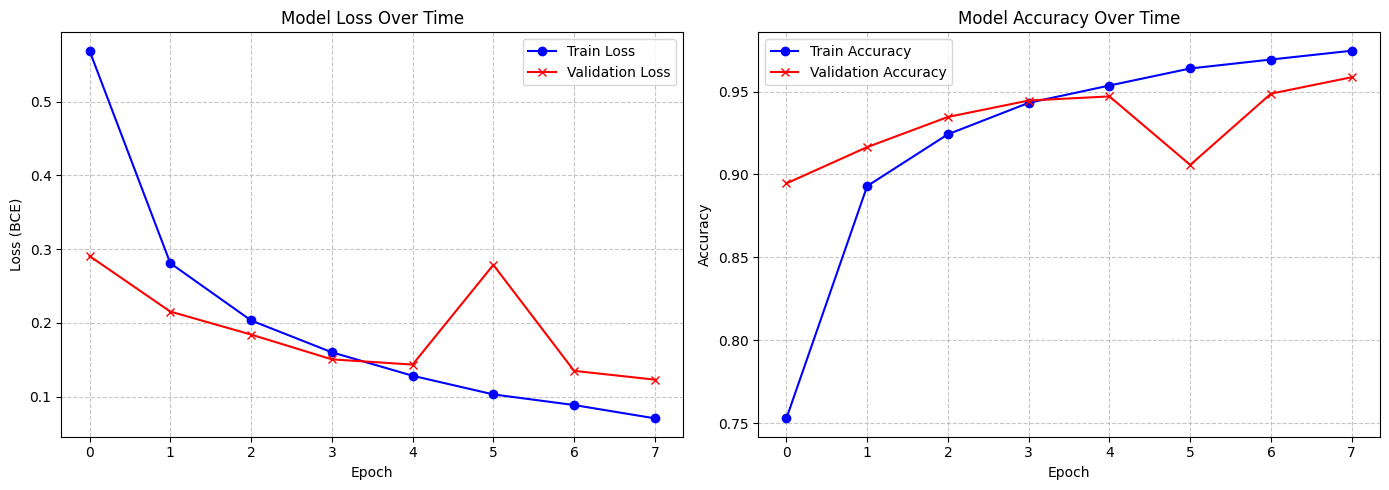

In [175]:
# Create a figure with 2 side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Loss ---
ax1.plot(train_loss_total, label='Train Loss', color='blue', marker='o')
ax1.plot(val_loss_total, label='Validation Loss', color='red', marker='x')
ax1.set_title('Model Loss Over Time')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (BCE)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Accuracy ---
ax2.plot(train_acc_total, label='Train Accuracy', color='blue', marker='o')
ax2.plot(val_acc_total, label='Validation Accuracy', color='red', marker='x')
ax2.set_title('Model Accuracy Over Time')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlapping and display the graph
plt.tight_layout()
plt.show()

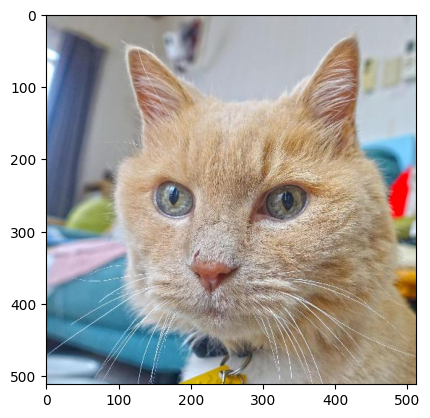


Prediction: 



array(['cat'], dtype=object)

In [181]:
# Inference

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).to(device)

    output = model(image.unsqueeze(0))
    output = torch.argmax(output, axis = 1).item()
    target = le.inverse_transform([output])
    return target


image = Image.open("/kaggle/input/animal-faces/afhq/val/cat/flickr_cat_000180.jpg")
plt.imshow(image)
plt.show()


## Predict
print()
print("Prediction: \n")
predict_image("/kaggle/input/animal-faces/afhq/val/cat/flickr_cat_000180.jpg")

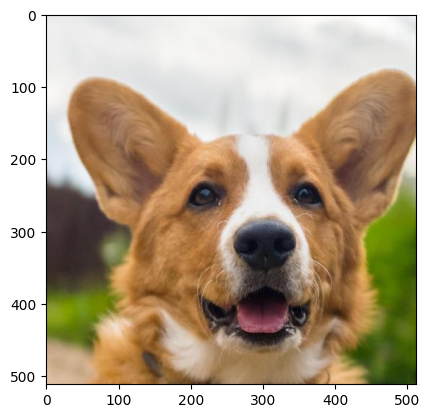


Prediction: 



array(['dog'], dtype=object)

In [182]:
image = Image.open("/kaggle/input/animal-faces/afhq/val/dog/flickr_dog_000205.jpg")
plt.imshow(image)
plt.show()


## Predict
print()
print("Prediction: \n")
predict_image("/kaggle/input/animal-faces/afhq/val/dog/flickr_dog_000205.jpg")

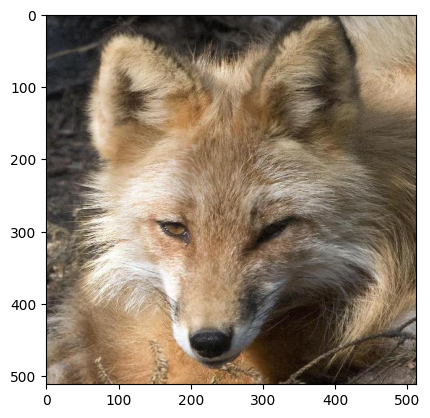


Prediction: 



array(['wild'], dtype=object)

In [183]:
image = Image.open("/kaggle/input/animal-faces/afhq/val/wild/flickr_wild_000206.jpg")
plt.imshow(image)
plt.show()


## Predict
print()
print("Prediction: \n")
predict_image("/kaggle/input/animal-faces/afhq/val/wild/flickr_wild_000206.jpg")